# 🏆 Scoring Multicriterio

## ¿Por qué un scoring y no simplemente el ranking de ganancia?

El ranking de ganancia mensual responde solo una pregunta. Pero un conductor
real tiene múltiples criterios al momento de comprar un auto:

- ¿Cuánto capital tengo disponible?
- ¿Priorizo ganar más o perder menos en el peor escenario?
- ¿Me importa la resiliencia ante una devaluación?
- ¿Qué tan rápido quiero recuperar la inversión?

El **scoring multicriterio** construye un puntaje 0-100 para cada auto
combinando todas estas dimensiones con pesos configurables según el perfil
del conductor. Permite comparar autos que no son directamente comparables
con un solo número.

## Dimensiones del scoring

| Dimensión | Variable base | ¿Qué mide? |
|---|---|---|
| Rentabilidad | Ganancia P50 Montecarlo | Ganancia típica mensual |
| Resiliencia | Ganancia P10 Montecarlo | Peor escenario probable |
| Accesibilidad | Precio de compra | Qué tan fácil es entrar |
| Payback | Meses para recuperar inversión | Velocidad de retorno |
| Estabilidad | Desvío estándar Montecarlo | Predictibilidad de ingresos |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append("..")

# Cargar resultados de Montecarlo
# (necesitamos correr la simulación de nuevo o cargar los resultados)
from src.modelo import PARAMETROS, MANTENIMIENTO_POR_KM_ARS
import requests
from bs4 import BeautifulSoup

def get_tipo_cambio():
    url = "https://dolarhoy.com/"
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    valores = soup.find_all("div", class_="val")
    venta_blue = valores[5].text.strip().replace("$","").replace(".","").replace(",",".")
    return float(venta_blue)

TIPO_CAMBIO = get_tipo_cambio()
df = pd.read_csv("../data/processed/precios_autos_procesado.csv")
precio_mediano = df.groupby("modelo")["precio_usd"].median()

np.random.seed(42)
N = 10_000
p = PARAMETROS

consumo_por_modelo = {
    "Toyota Etios":        8.5, "Toyota Corolla":      9.0,
    "Toyota Yaris":        8.0, "Chevrolet Prisma":    8.5,
    "Chevrolet Onix Plus": 7.8, "Renault Logan":       8.0,
    "Nissan Versa":        9.0, "VW Virtus":           8.5,
    "VW Voyage":           9.5, "VW Gol":              9.0,
    "Ford Ka":             8.0, "Ford Fiesta":         9.0,
    "Fiat Siena":          9.5, "Fiat Cronos":         8.4,
    "Peugeot 208":         7.5,
}

tiene_gnc = {
    "Toyota Etios": False, "Toyota Corolla": False, "Toyota Yaris": False,
    "Chevrolet Prisma": True, "Chevrolet Onix Plus": False, "Renault Logan": True,
    "Nissan Versa": False, "VW Virtus": False, "VW Voyage": True, "VW Gol": True,
    "Ford Ka": False, "Ford Fiesta": False, "Fiat Siena": True,
    "Fiat Cronos": True, "Peugeot 208": False,
}

def simular(precio_usd, consumo, gnc, mant_km, n=N):
    nafta  = np.random.normal(p["precio_nafta_ars_litro"], p["precio_nafta_ars_litro"]*0.15, n)
    gncp   = np.random.normal(p["precio_gnc_ars_m3"], p["precio_gnc_ars_m3"]*0.15, n)
    km_dia = np.abs(np.random.normal(p["km_diarios"], 20, n))
    tc     = np.abs(np.random.normal(TIPO_CAMBIO, 150, n))
    ing    = np.random.triangular(600_000, 2_000_000, 2_800_000, n)

    km_mes = km_dia * p["dias_laborales_mes"]
    costo_comb = (km_mes/100)*10*gncp if gnc else (km_mes/100)*consumo*nafta
    precio_ars = precio_usd * tc
    # Modelo v2: valor residual, mantenimiento por km, seguro/patente sobre el valor
    amort = (precio_ars * (1 - p["valor_residual_pct"]) / p["vida_util_km"]) * km_mes
    mantenimiento = mant_km * km_mes
    seguro = np.maximum(precio_ars * p["seguro_pct_mensual"], p["seguro_piso_ars"])
    patente = (precio_ars * p["valor_fiscal_pct"] * p["patente_pct_anual"]) / 12
    ing_neto = ing * (1 - p["comision_cabify"])
    ganancia_ars = ing_neto - costo_comb - amort - mantenimiento - seguro - patente
    return ganancia_ars / tc

resultados_mc = {}
for modelo in consumo_por_modelo:
    resultados_mc[modelo] = simular(precio_mediano[modelo], consumo_por_modelo[modelo],
                                    tiene_gnc[modelo], MANTENIMIENTO_POR_KM_ARS[modelo])

print("Simulación lista ✅")

Simulación lista ✅


### Construcción del scoring

Cada dimensión se normaliza al rango 0-100 usando **min-max scaling**:

score = (valor - min) / (max - min) * 100

Esto hace que el peor auto en cada dimensión reciba 0 y el mejor reciba 100,
permitiendo comparar dimensiones que tienen unidades distintas (USD, meses, etc.).

Los pesos de cada dimensión suman 1.0 y son configurables según el perfil
del conductor.

In [2]:
def minmax(serie):
    return (serie - serie.min()) / (serie.max() - serie.min()) * 100

# Construir tabla de métricas base
metricas = pd.DataFrame({
    "p50_usd":      {m: np.percentile(resultados_mc[m], 50) for m in resultados_mc},
    "p10_usd":      {m: np.percentile(resultados_mc[m], 10) for m in resultados_mc},
    "std_usd":      {m: np.std(resultados_mc[m])            for m in resultados_mc},
    "precio_usd":   precio_mediano,
    "gnc":          tiene_gnc,
})

# Payback: solo tiene sentido si la ganancia mediana es positiva.
# Un P50 negativo implica que la inversión nunca se recupera → NaN
metricas["payback_meses"] = np.where(
    metricas["p50_usd"] > 0,
    metricas["precio_usd"] / metricas["p50_usd"],
    np.nan
)

# Normalizar — para precio y payback invertimos (menor es mejor)
metricas["score_rentabilidad"] = minmax(metricas["p50_usd"])
metricas["score_resiliencia"]  = minmax(metricas["p10_usd"])
metricas["score_accesibilidad"]= minmax(-metricas["precio_usd"])   # invertido
metricas["score_payback"]      = minmax(-metricas["payback_meses"]).fillna(0)  # invertido; sin payback → 0
metricas["score_estabilidad"]  = minmax(-metricas["std_usd"])       # invertido

print("Métricas normalizadas:")
score_cols = [c for c in metricas.columns if c.startswith("score_")]
print(metricas[score_cols].round(1).to_string())

Métricas normalizadas:
                     score_rentabilidad  score_resiliencia  score_accesibilidad  score_payback  score_estabilidad
Chevrolet Onix Plus                32.3               31.8                 37.8            0.0               44.2
Chevrolet Prisma                   92.4               92.2                 90.8          100.0               78.4
Fiat Cronos                        73.6               73.9                 40.2           99.8               81.5
Fiat Siena                        100.0              100.0                100.0          100.0              100.0
Ford Fiesta                        43.5               42.4                 79.6           99.2               29.4
Ford Ka                            54.5               54.0                 85.8           99.7               47.4
Nissan Versa                       29.6               29.9                 57.1            0.0               38.2
Peugeot 208                        24.6               25.5       

### Perfiles de conductor

Definí tres perfiles con distintas prioridades para mostrar que el
"mejor auto" depende del contexto de cada conductor:

- **Perfil A — Maximizador:** tiene capital disponible, prioriza ganancia mensual
- **Perfil B — Conservador:** prioriza no perder plata en el peor escenario
- **Perfil C — Capital limitado:** prioriza precio de entrada bajo y payback rápido

In [3]:
perfiles = {
    "Maximizador": {
        "score_rentabilidad": 0.40,
        "score_resiliencia":  0.20,
        "score_accesibilidad":0.10,
        "score_payback":      0.20,
        "score_estabilidad":  0.10,
    },
    "Conservador": {
        "score_rentabilidad": 0.20,
        "score_resiliencia":  0.40,
        "score_accesibilidad":0.10,
        "score_payback":      0.10,
        "score_estabilidad":  0.20,
    },
    "Capital limitado": {
        "score_rentabilidad": 0.20,
        "score_resiliencia":  0.10,
        "score_accesibilidad":0.40,
        "score_payback":      0.25,
        "score_estabilidad":  0.05,
    },
}

for perfil, pesos in perfiles.items():
    metricas[f"score_{perfil}"] = sum(
        metricas[dim] * peso for dim, peso in pesos.items()
    )

# Mostrar ranking por perfil
print("=== RANKING POR PERFIL ===\n")
for perfil in perfiles:
    col = f"score_{perfil}"
    ranking = metricas[col].sort_values(ascending=False)
    print(f"Perfil {perfil}:")
    for i, (modelo, score) in enumerate(ranking.items(), 1):
        gnc_tag = "🟢" if tiene_gnc[modelo] else "🔵"
        print(f"  {i:2}. {gnc_tag} {modelo:<20} {score:.1f}/100")
    print()

=== RANKING POR PERFIL ===

Perfil Maximizador:
   1. 🟢 Fiat Siena           100.0/100
   2. 🟢 VW Voyage            94.7/100
   3. 🟢 Chevrolet Prisma     92.3/100
   4. 🟢 VW Gol               92.0/100
   5. 🟢 Renault Logan        90.1/100
   6. 🟢 Fiat Cronos          76.3/100
   7. 🔵 Ford Ka              65.9/100
   8. 🔵 Ford Fiesta          56.6/100
   9. 🔵 Toyota Etios         52.2/100
  10. 🔵 Chevrolet Onix Plus  27.5/100
  11. 🔵 Nissan Versa         27.3/100
  12. 🔵 VW Virtus            26.6/100
  13. 🔵 Peugeot 208          21.0/100
  14. 🔵 Toyota Yaris         16.2/100
  15. 🔵 Toyota Corolla       0.0/100

Perfil Conservador:
   1. 🟢 Fiat Siena           100.0/100
   2. 🟢 VW Voyage            94.1/100
   3. 🟢 VW Gol               91.2/100
   4. 🟢 Chevrolet Prisma     90.1/100
   5. 🟢 Renault Logan        88.9/100
   6. 🟢 Fiat Cronos          74.6/100
   7. 🔵 Ford Ka              60.5/100
   8. 🔵 Ford Fiesta          49.4/100
   9. 🔵 Toyota Etios         45.9/100
  10. 🔵 Chevrolet 

### Visualización del scoring por perfil

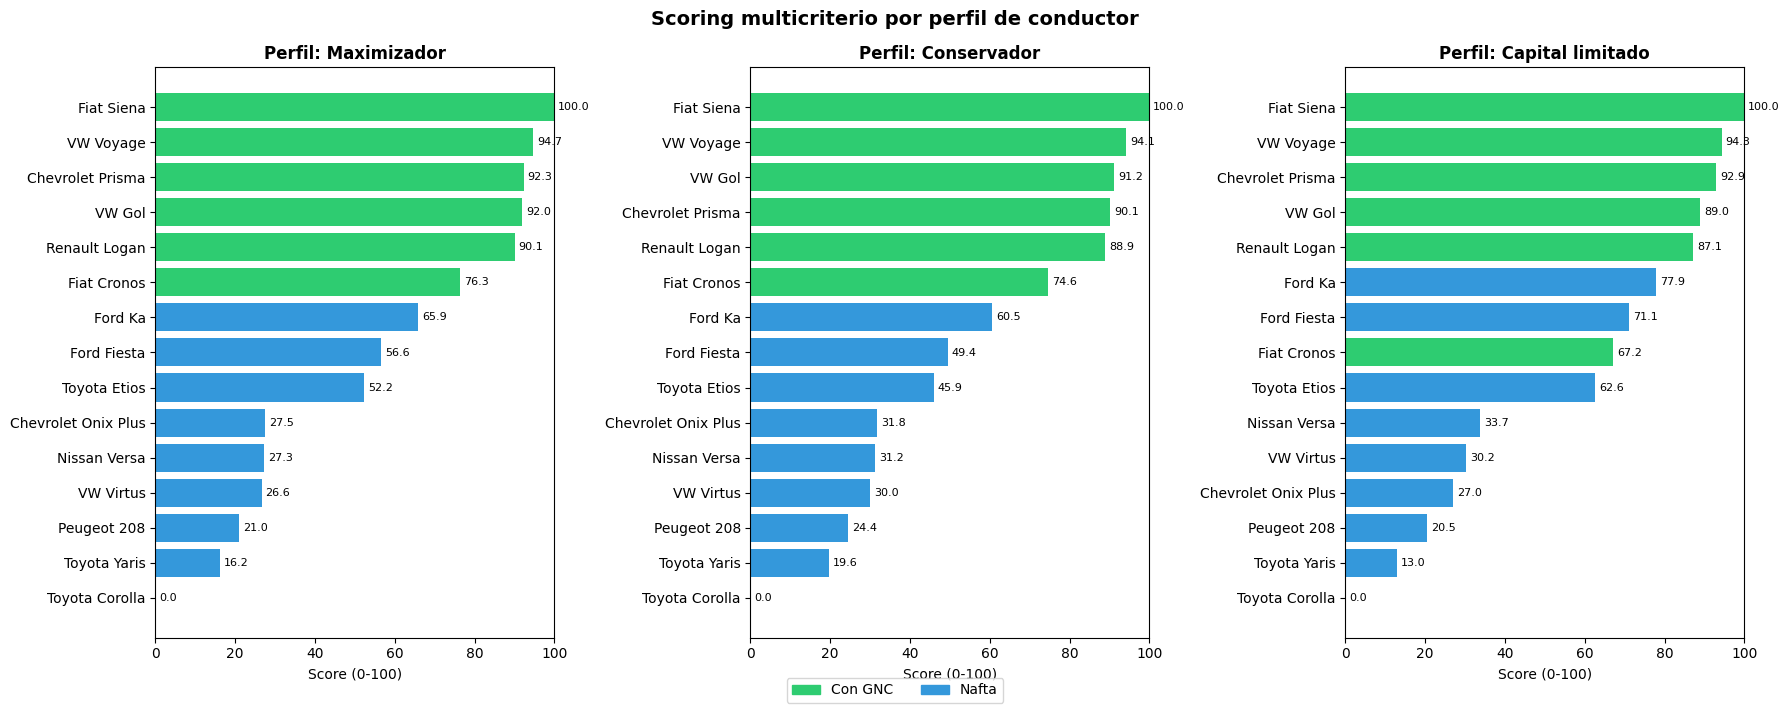

Gráfico guardado.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Scoring multicriterio por perfil de conductor", fontsize=14, fontweight="bold")

for ax, perfil in zip(axes, perfiles):
    col = f"score_{perfil}"
    df_plot = metricas[col].sort_values(ascending=True)
    colores = ["#2ecc71" if tiene_gnc[m] else "#3498db" for m in df_plot.index]

    ax.barh(df_plot.index, df_plot.values, color=colores)
    ax.set_title(f"Perfil: {perfil}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Score (0-100)")
    ax.set_xlim(0, 100)
    for i, v in enumerate(df_plot.values):
        ax.text(v + 1, i, f"{v:.1f}", va="center", fontsize=8)

patch_gnc   = mpatches.Patch(color="#2ecc71", label="Con GNC")
patch_nafta = mpatches.Patch(color="#3498db", label="Nafta")
fig.legend(handles=[patch_gnc, patch_nafta], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("../reports/figures/05_scoring_perfiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Interpretación del scoring multicriterio (modelo v2)

Los tres perfiles confirman que el **Fiat Siena domina en cualquier contexto**,
obteniendo el primer puesto con ~100/100 en los tres perfiles: es a la vez el
más barato, el más rentable, el más resiliente, el más estable y el de
mantenimiento más económico del análisis.

**Perfil Maximizador:** el top 6 está compuesto íntegramente por autos con GNC
(Siena, Voyage, Prisma, Gol, Logan y Cronos). La rentabilidad mensual es tan
superior en estos modelos que ningún auto a nafta puede competir con ellos
cuando el objetivo es maximizar ganancias.

**Perfil Conservador:** el ranking casi no cambia respecto al Maximizador, pero
por una razón distinta. Los autos con GNC no solo ganan más — generan ganancias
más **predecibles**: los 5 GNC baratos tienen probabilidad de mes positivo
superior al 92%, mientras que en el modelo v2 varios autos a nafta tienen P50
negativo (Versa, Peugeot 208, Yaris, Corolla) — directamente pierden plata en
el escenario típico. El VW Gol sube al 3° puesto por su alta estabilidad.

**Perfil Capital limitado:** es el perfil donde el ranking cambia más. El
**Ford Ka sube al puesto 6 y el Ford Fiesta al 7**, desplazando al Fiat Cronos
al 8° — que a pesar del GNC tiene un precio de entrada alto ($17.000 USD,
unidades casi 0km) que en el modelo v2 castiga triple: amortización, seguro y
patente. Para un conductor con presupuesto acotado, un auto barato a nafta
puede competir con los GNC caros. Esto demuestra que **el GNC no compensa
cualquier precio de compra**.

**Conclusión general:** la decisión de qué auto comprar no tiene una respuesta
única — depende del perfil del conductor. Sin embargo, el Fiat Siena con GNC es
robusto ante cualquier perfil: es el más barato del análisis, tiene GNC, el
mantenimiento más económico y recupera la inversión en ~14 meses.

---

## 🏁 Conclusiones generales del análisis

Este proyecto analizó 3.780 publicaciones reales de MercadoLibre (2.440 elegibles
tras el filtro regulatorio de antigüedad y la limpieza de outliers) para determinar
qué auto es más rentable para trabajar en Cabify en AMBA, usando un modelo de
costos v2 que incluye combustible, amortización con valor residual, mantenimiento
por km, y seguro/patente proporcionales al valor del auto.

### Hallazgos principales

1. **El Fiat Siena con GNC es el auto más rentable en cualquier perfil de
   conductor.** Con una ganancia neta de ~$626 USD/mes (modelo determinístico) y
   un payback de ~14 meses, domina el ranking porque combina el precio de entrada
   más bajo del análisis ($8.653 USD), GNC y el mantenimiento más barato (80 ARS/km).

2. **El GNC es el factor diferenciador más importante.** Con el precio actual de
   la nafta, los autos a GNC gastan ~$195.000 ARS/mes en combustible contra
   $595.000-$714.000 de los de nafta. Los 6 primeros puestos del ranking son
   todos autos con GNC.

3. **El mantenimiento es el costo silencioso que el modelo v1 ignoraba.**
   Prorratear cubiertas, frenos, service y consumibles cuesta $312.000-$468.000
   ARS/mes (~$208-312 USD) según el modelo. Incorporarlo bajó la ganancia
   mensual promedio del análisis de ~$521 a ~$270 USD (-48%) y volvió inviables
   a varios autos.

4. **Cuatro autos no son negocio para Cabify con ingreso bruto de $2M:** en la
   simulación de Montecarlo, Nissan Versa, Peugeot 208, Toyota Yaris y Toyota
   Corolla tienen ganancia mediana negativa o nula. El Corolla es el caso
   extremo: -$236 USD/mes en el escenario típico y solo 23% de probabilidad de
   mes positivo — su precio de entrada (~$22.600 USD) genera amortización,
   seguro y patente imposibles de cubrir.

5. **El precio de compra pega triple en el modelo v2:** amortización, seguro
   (1,2% mensual del valor) y patente (4,5% anual del valor fiscal) son
   proporcionales al valor del auto. Por eso el Fiat Cronos, con GNC pero caro
   ($17.000 USD), cae al 6°-8° puesto según el perfil.

6. **El ingreso bruto sigue siendo la variable de mayor impacto (±$246 USD ante
   ±20%)**, seguida del tipo de cambio (-$146/+$199) y los km diarios (±$86).
   El mantenimiento (±$44) entra cuarto, por encima del combustible para un
   auto con GNC. El conductor tiene más poder sobre su rentabilidad optimizando
   sus horas de trabajo que preocupándose por los costos del auto.

### Limitaciones del análisis

- Los precios de compra son medianas del mercado de **usados** en MercadoLibre. Un auto más nuevo o más caro que el mediano va a tener menor
  rentabilidad que la estimada.
- Los ingresos brutos están basados en un relevamiento de 25+ choferes activos
  en AMBA. Pueden variar significativamente según zona, horario y temporada.
- Los costos de mantenimiento por km son estimaciones (service oficial +
  consumibles); el valor residual del 35% y los coeficientes de seguro/patente
  son reglas aproximadas de mercado, no cotizaciones reales por modelo.
- El modelo no incluye reparaciones no planificadas ni días perdidos por falla
  mecánica — variables difíciles de estimar sin datos históricos.
- El análisis es válido para AMBA. En el interior del país los precios de
  combustible, seguros y autos usados pueden diferir significativamente.
- El Fiat Siena elegible es mayormente año 2016 con ~124.500 km — la unidad más
  vieja permitida. Quien lo compre debería considerar que en pocos años quedará
  fuera del límite regulatorio de antigüedad.

### Próximos pasos posibles
- Reemplazar las reglas de seguro/patente por cotizaciones reales por modelo
- Incorporar datos de confiabilidad mecánica por modelo (JD Power, foros)
- Modelar el impacto de días perdidos por rotura en la rentabilidad anual
- Expandir el análisis a otras ciudades (Córdoba, Rosario)
- Actualizar el dataset periódicamente para seguir la evolución de precios